[Text(1, 0, '0'), Text(1, 1, '1'), Text(1, 2, '2'), Text(1, 3, '3')]

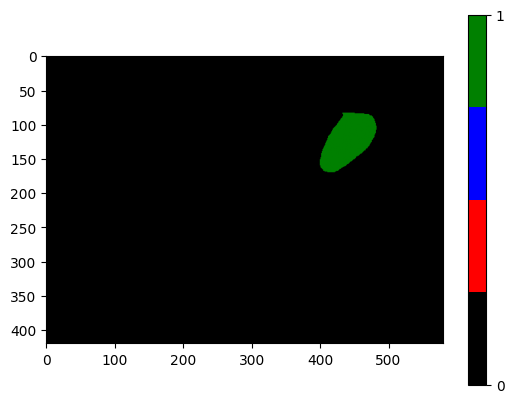

In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

im = Image.open('/home/asavari/foundation_model/datasets/US_Nerve/masks/1_1.tif')
im_arr = np.array(im)
colors = ['black', 'red', 'blue', 'green']
cmap = ListedColormap(colors)
plt.imshow(im,cmap=cmap)


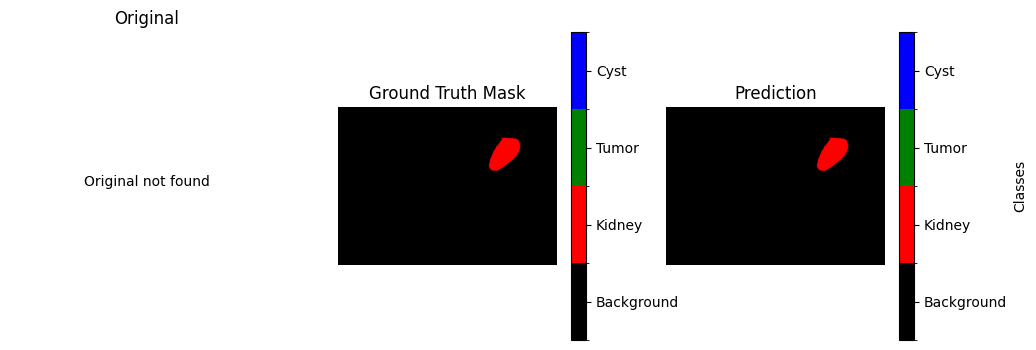

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.colorbar import Colorbar

# Example class names and colors (you can modify these)
class_names = ["Background", "Kidney", "Tumor", "Cyst"]
colors = ["black", "red", "green", "blue"]

# Create a discrete colormap
cmap = ListedColormap(colors)
norm = BoundaryNorm(np.arange(len(class_names) + 1) - 0.5, len(class_names))

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# --- Original ---
if orig is not None:
    axes[0].imshow(np.array(orig))
else:
    axes[0].text(0.5, 0.5, "Original not found", ha="center")
axes[0].set_title("Original")
axes[0].axis("off")

# --- Mask (Ground Truth) ---
if mask is not None:
    im_mask = axes[1].imshow(np.array(mask), cmap=cmap, norm=norm)
else:
    axes[1].text(0.5, 0.5, "Mask not found", ha="center")
axes[1].set_title("Ground Truth Mask")
axes[1].axis("off")

# --- Prediction ---
if pred_array is not None:
    im_pred = axes[2].imshow(pred_array, cmap=cmap, norm=norm)
else:
    axes[2].text(0.5, 0.5, "Prediction not available", ha="center")
axes[2].set_title("Prediction")
axes[2].axis("off")

# Add colorbars (legends) for mask and prediction
cbar1 = fig.colorbar(im_mask, ax=axes[1], ticks=range(len(class_names)))
cbar1.ax.set_yticklabels(class_names)
cbar1.set_label("Classes")

cbar2 = fig.colorbar(im_pred, ax=axes[2], ticks=range(len(class_names)))
cbar2.ax.set_yticklabels(class_names)
cbar2.set_label("Classes")


In [13]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# List all available colormap names
# print("Available Matplotlib Colormaps:")
# for cmap_name in plt.colormaps:
#     print(cmap_name)

# To get the colors of a specific colormap, for example 'viridis':
colormap = cm.get_cmap('viridis')

# You can access the colors as an array of RGBA values (normalized to 0-1)
# For a continuous colormap, you can sample it at various points.
# For example, to get 256 colors from 'viridis':
num_colors = 256
colors = colormap(range(num_colors))
colors

/tmp/ipykernel_1381150/9358575.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('viridis')


array([[0.267004, 0.004874, 0.329415, 1.      ],
       [0.26851 , 0.009605, 0.335427, 1.      ],
       [0.269944, 0.014625, 0.341379, 1.      ],
       ...,
       [0.974417, 0.90359 , 0.130215, 1.      ],
       [0.983868, 0.904867, 0.136897, 1.      ],
       [0.993248, 0.906157, 0.143936, 1.      ]], shape=(256, 4))

In [1]:
from loss.loss import FocalLoss
import torch

t1 = torch.randn((10,5,128,128)) #B x C x H x W
t2 = torch.randn((10,5,128,128)) 

l = FocalLoss()
l(t1,t2)

After First Step: torch.Size([10, 5, 16384])
After Transpose: torch.Size([10, 16384, 5])
End of the loop: torch.Size([163840, 5])
Input was fiddled with: torch.Size([163840, 5])
Target was fiddled with: torch.Size([819200, 1])


RuntimeError: Size does not match at dimension 0 expected index [819200, 1] to be no larger than self [163840, 5] apart from dimension 1